In [1]:
# Mini Visualization Dashboard - Titanic Dataset

## Data Science with Python Internship – Task 4

### Submitted By: Jayesh Mundle

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Dataset Overview

In [7]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Observation

The dataset contains missing values in Age, Cabin, and Embarked columns.
These missing values need to be handled before analysis.

# Data Cleaning

In [11]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df = df.drop(columns=["Cabin"], errors="ignore")

print("Missing Values After Cleaning:\n")
print(df.isnull().sum())

Missing Values After Cleaning:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Feature Engineering

In [12]:
# Create Family Size feature
df["FamilySize"] = df["SibSp"] + df["Parch"]

# Create Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,30,50,80],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Adult


# Visualization 1 - Age Distribution

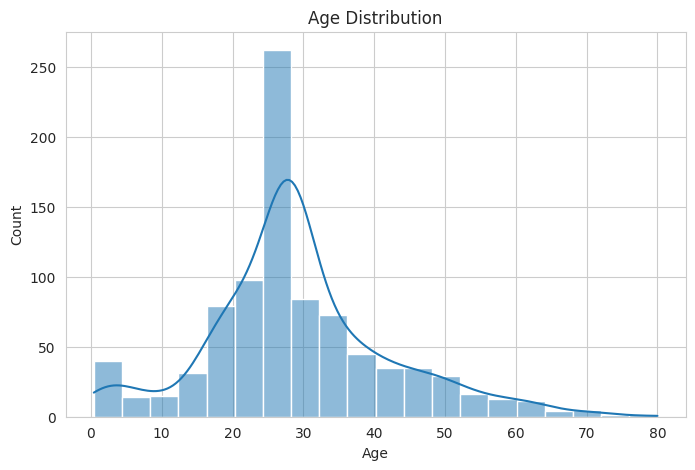

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

### Insight

Most passengers were between 20 and 40 years old, indicating that young adults formed the largest group on the Titanic.

# Visualization 2 - Survival Rate by Gender

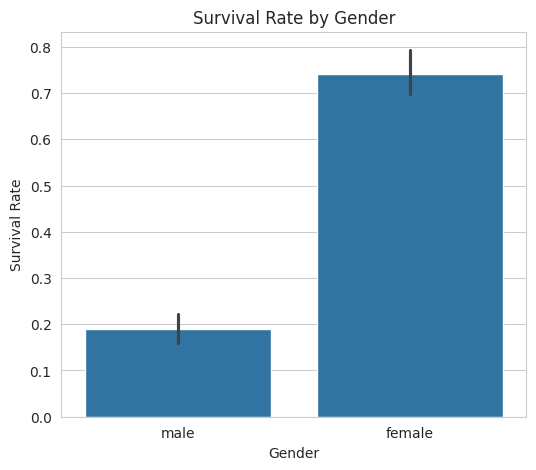

In [14]:
plt.figure(figsize=(6,5))

sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")

plt.xlabel("Gender")

plt.ylabel("Survival Rate")

plt.show()

### Insight

Female passengers had a much higher survival rate than male passengers.

# Visualization 3 - Fare Distribution by Passenger Class

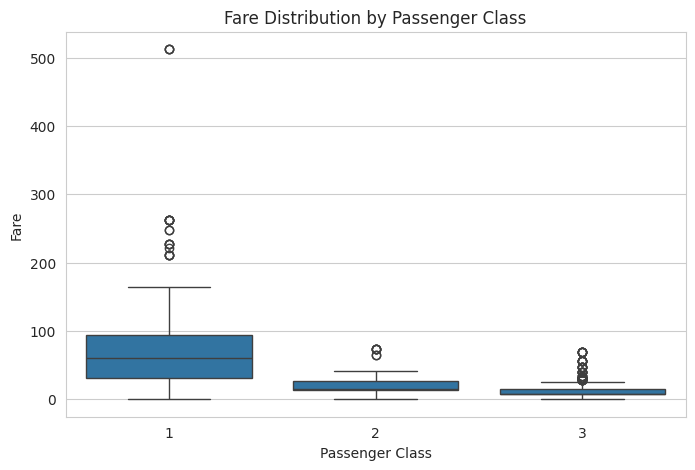

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Pclass", y="Fare", data=df)

plt.title("Fare Distribution by Passenger Class")

plt.xlabel("Passenger Class")

plt.ylabel("Fare")

plt.show()

### Insight

Passengers in first class generally paid significantly higher fares than passengers in second and third class.


# Visualization 4 - Age vs Fare

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Age",
    y="Fare",
    hue="Survived",
    data=df,
    alpha=0.7
)

plt.title("Age vs Fare (Colored by Survival)")

plt.show()

### Insight

Passengers with higher fares were more likely to belong to higher classes, and many of them survived.

# Visualization 5 - Correlation Heatmap

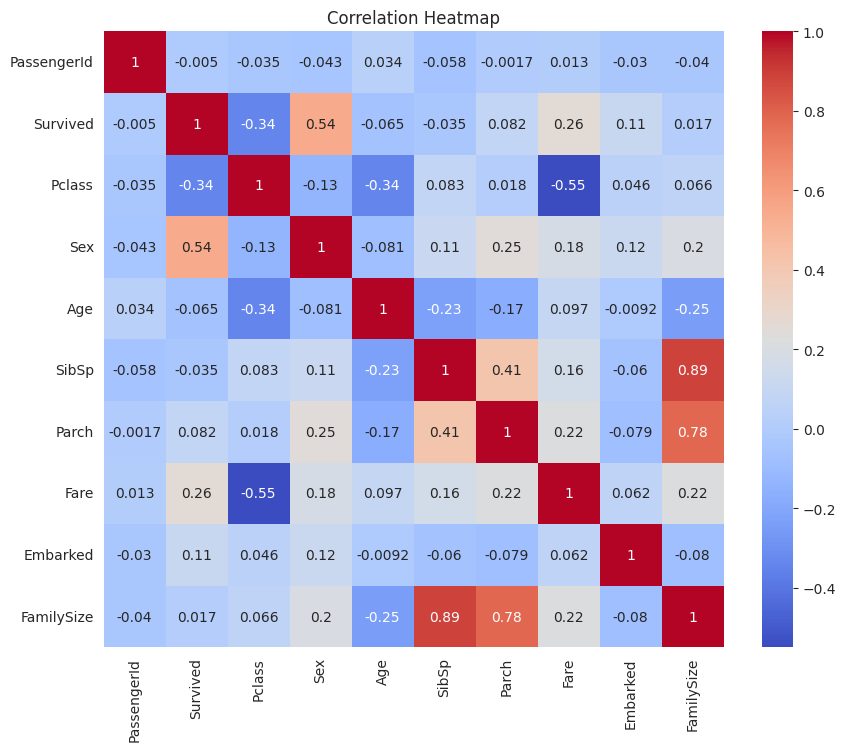

In [16]:
heatmap_df = df.copy()

heatmap_df["Sex"] = heatmap_df["Sex"].map({
    "male":0,
    "female":1
})

heatmap_df["Embarked"] = heatmap_df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

Passenger class, fare, and gender show stronger relationships with survival than age.

# Visualization 6 - Survival by Family Size

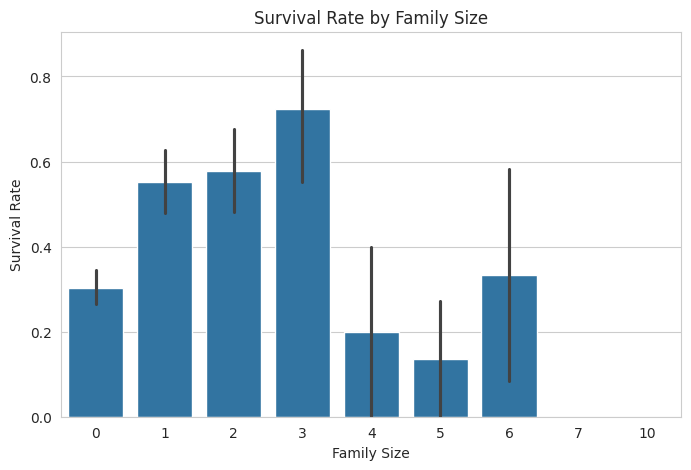

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="FamilySize",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Family Size")

plt.xlabel("Family Size")

plt.ylabel("Survival Rate")

plt.show()

### Insight

Passengers travelling with small families had better survival rates than those travelling alone or with very large families.

## Conclusion

- The Titanic dataset was successfully cleaned by handling missing values.
- New features such as FamilySize and AgeGroup were created.
- Six visualizations were used to explore the data.
- Female passengers showed a higher survival rate than males.
- First-class passengers generally paid higher fares and had better survival chances.
- Family size and passenger class both influenced survival.
- Visualizations helped reveal meaningful patterns in the dataset.